# MIT-BIH Data Pipeline

Downloads all 48 MIT-BIH Arrhythmia Database records, applies a bandpass filter,
detects R-peaks, extracts 360-sample beat windows, Z-score normalises each beat,
maps annotations to 5 AAMI classes, and saves the result to `data/`.

**Run this notebook once** (or when adding new records).  
Output files used by `02_train_and_export.ipynb`:
- `data/all_beats.npy`  — float32 array, shape (N, 360)
- `data/all_labels.npy` — int64 array,   shape (N,)

| Class | AAMI label | MIT-BIH symbols |
|-------|-----------|------------------|
| 0 | N — Normal | N L R e j |
| 1 | S — Supraventricular ectopic | A a J S |
| 2 | V — Ventricular ectopic | V E |
| 3 | F — Fusion | F |
| 4 | Q — Unclassifiable | / f Q |

In [7]:
import wfdb
import wfdb.processing
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

In [8]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=360, order=4):
    """4th-order Butterworth bandpass: removes baseline wander and high-freq noise."""
    nyq = fs / 2
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, signal)

def normalize_beat(beat):
    """Z-score normalise a single beat. Must match the STM32 firmware normalisation."""
    mean = beat.mean()
    std  = beat.std()
    return (beat - mean) / std if std > 1e-6 else beat - mean

# MIT-BIH symbol → 5-class AAMI mapping
LABEL_MAP = {
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,   # Normal
    'A': 1, 'a': 1, 'J': 1, 'S': 1,             # Supraventricular ectopic
    'V': 2, 'E': 2,                               # Ventricular ectopic
    'F': 3,                                        # Fusion
    '/': 4, 'f': 4, 'Q': 4,                      # Unclassifiable
}

WINDOW = 180   # ±180 samples around each R-peak → 360-sample beat
FS     = 360   # MIT-BIH sampling rate (Hz)

## Single-Record Exploration (Record 100)
Visual sanity check before processing all 48 records.

In [9]:
wfdb.dl_database('mitdb', dl_dir='../data', records=['100'])
record     = wfdb.rdrecord('../data/100')
annotation = wfdb.rdann('../data/100', 'atr')

signal   = record.p_signal[:, 0]          # MLII lead
filtered = bandpass_filter(signal)
peaks    = wfdb.processing.gqrs_detect(filtered, fs=FS)

print(f"Sampling rate : {record.fs} Hz")
print(f"Signal length : {len(signal)} samples ({len(signal)/FS/60:.1f} min)")
print(f"Beats detected: {len(peaks)}")
print(f"Label counts  : {dict(zip(*np.unique(annotation.symbol, return_counts=True)))}")

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
Sampling rate : 360 Hz
Signal length : 650000 samples (30.1 min)
Beats detected: 2272
Label counts  : {np.str_('+'): np.int64(1), np.str_('A'): np.int64(33), np.str_('N'): np.int64(2239), np.str_('V'): np.int64(1)}


In [ ]:
PLOT_SAMPLES = 1800   # first 5 seconds
visible_peaks = peaks[peaks < PLOT_SAMPLES]

# gqrs_detect returns QRS onset, not the exact peak sample.
# Search ±20 samples around each onset to find the true local maximum.
SEARCH = 20
peak_y = np.array([
    filtered[max(0, p - SEARCH) : p + SEARCH + 1].max()
    for p in visible_peaks
])

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(signal[:PLOT_SAMPLES], color='steelblue', lw=0.9, label='Raw ECG')
axes[0].set_title('Record 100 — Raw vs Filtered ECG (first 5 s)', fontsize=13)
axes[0].set_ylabel('Amplitude (mV)')
axes[0].legend()

axes[1].plot(filtered[:PLOT_SAMPLES], color='darkorange', lw=0.9, label='Filtered ECG')
axes[1].plot(
    visible_peaks,
    peak_y,
    '\^r', markersize=9, label='R-peaks'
)
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_xlabel('Sample index (360 Hz)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/ecg_rpeak_preview.png', dpi=120)
plt.show()

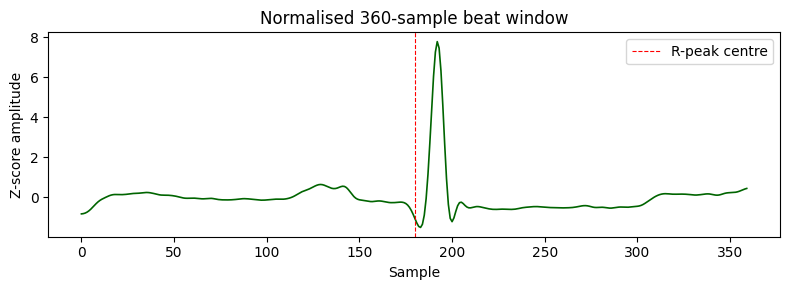

In [11]:
# Show one normalised beat window
sample_peak = peaks[5]
sample_beat = normalize_beat(filtered[sample_peak - WINDOW : sample_peak + WINDOW])

plt.figure(figsize=(8, 3))
plt.plot(sample_beat, color='darkgreen', lw=1.2)
plt.axvline(WINDOW, color='red', ls='--', lw=0.8, label='R-peak centre')
plt.title('Normalised 360-sample beat window')
plt.xlabel('Sample'); plt.ylabel('Z-score amplitude')
plt.legend(); plt.tight_layout(); plt.show()

## Full Dataset — All 48 Records
Downloads each record from PhysioNet, extracts beats, and accumulates into arrays.  
Takes ~5–10 min on first run (network I/O bound).

In [ ]:
ALL_RECORDS = [
    '100','101','102','103','104','105','106','107',
    '108','109','111','112','113','114','115','116',
    '117','118','119','121','122','123','124','200',
    '201','202','203','205','207','208','209','210',
    '212','213','214','215','217','219','220','221',
    '222','223','228','230','231','232','233','234',
]

all_beats  = []
all_labels = []

for i, rec in enumerate(ALL_RECORDS):
    try:
        wfdb.dl_database('mitdb', dl_dir='../data', records=[rec])
        record     = wfdb.rdrecord(f'../data/{rec}')
        annotation = wfdb.rdann(f'../data/{rec}', 'atr')
        signal     = record.p_signal[:, 0]
        filtered   = bandpass_filter(signal)
        peaks      = wfdb.processing.gqrs_detect(filtered, fs=FS)

        for peak in peaks:
            if peak - WINDOW >= 0 and peak + WINDOW <= len(filtered):
                beat   = normalize_beat(filtered[peak - WINDOW : peak + WINDOW])
                symbol = annotation.symbol[np.argmin(np.abs(annotation.sample - peak))]
                if symbol in LABEL_MAP:
                    all_beats.append(beat)
                    all_labels.append(LABEL_MAP[symbol])

        print(f"[{i+1:2d}/48]  {rec}  — {len(peaks)} beats")
    except Exception as e:
        print(f"  Skipped {rec}: {e}")

all_beats  = np.array(all_beats,  dtype=np.float32)
all_labels = np.array(all_labels, dtype=np.int64)
print(f"\nTotal beats extracted : {len(all_beats)}")
print(f"Array shape           : {all_beats.shape}")

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files
[ 1/48]  100  — 2272 beats
Generating record list for: 101
Generating list of all files for: 101
Finished downloading files
[ 2/48]  101  — 1865 beats
Generating record list for: 102
Generating list of all files for: 102
Finished downloading files
[ 3/48]  102  — 2187 beats
Generating record list for: 103
Generating list of all files for: 103
Finished downloading files
[ 4/48]  103  — 2084 beats
Generating record list for: 104
Generating list of all files for: 104
Finished downloading files
[ 5/48]  104  — 2245 beats
Generating record list for: 105
Generating list of all files for: 105
Finished downloading files
[ 6/48]  105  — 2643 beats
Generating record list for: 106
Generating list of all files for: 106
Finished downloading files
[ 7/48]  106  — 2033 beats
Generating record list for: 107
Generating list of all files for: 107
Finished downloading files
[ 8/48]  107  — 2145 beats
Generati

In [ ]:
CLASS_NAMES = [
    'N — Normal',
    'S — Supravent.',
    'V — Ventricular',
    'F — Fusion',
    'Q — Unclassif.',
]
classes, counts = np.unique(all_labels, return_counts=True)

print("Class distribution:")
print(f"  {'Class':<22} {'Count':>7}  {'%':>6}")
print(f"  {'-'*38}")
for c, n in zip(classes, counts):
    print(f"  {CLASS_NAMES[c]:<22} {n:>7}  {n/len(all_labels)*100:>5.1f}%")

plt.figure(figsize=(7, 4))
plt.bar([CLASS_NAMES[c] for c in classes], counts, color='steelblue', edgecolor='white')
plt.title('Beat class distribution — all 48 MIT-BIH records')
plt.ylabel('Beat count'); plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.show()

In [ ]:
np.save('../data/all_beats.npy',  all_beats)
np.save('../data/all_labels.npy', all_labels)

print("Saved:")
print(f"  data/all_beats.npy   {all_beats.nbytes / 1e6:.1f} MB  shape={all_beats.shape}")
print(f"  data/all_labels.npy  {all_labels.nbytes / 1e3:.1f} KB  shape={all_labels.shape}")
print("\nNext: run 02_train_and_export.ipynb")